# From Empricial distribution of PFES, derive PFES partitioning threshold

# 1. Load data

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats

case = pd.read_csv('../data/case_pfes.tsv', delimiter='\t')
control = pd.read_csv('../data/control_pfes.tsv', delimiter='\t')

# case.replace(0, np.nan, inplace=True)
# control.replace(0, np.nan, inplace=True)

home_dir = '..'

SCORE_COLS     = ['PFES', 'PFES_Physicochemical', 'PFES_Structure',
                  'PFES_Domain', 'PFES_Modification', 'PFES_Function', 'PFES_PPI']
PRESENCE_BASED = {}#'PFES_Function', 'PFES_PPI'}
N_STEPS        = 10_000

print(f"Case:    {len(case):,} variants (read from ../data/case_pfes.tsv)")
print(f"Control: {len(control):,} variants (read from ../data/control_pfes.tsv)")

Case:    85,321 variants (read from ../data/case_pfes.tsv)
Control: 130,832 variants (read from ../data/control_pfes.tsv)


# 2. Build smoothed p-value lookup using KDE

For each score column:
- `p_case` = P(X ≤ v | case) — left-tail probability under the pathogenic distribution
- `p_control` = P(X ≥ v | control) — right-tail probability under the control distribution

**Partitioning criteria (p < 0.05):**

- **PF-Enriched**: p_control < 0.05 — the variant's score is significantly high relative to the control distribution, indicating enrichment for pathogenic-associated protein features
- **PF-Depleted**: p_case < 0.05 — the variant's score is significantly low relative to the pathogenic distribution, indicating enrichment for benign-associated protein features
- **PF-Neutral**: neither condition is met — the score is statistically consistent with both distributions



In [30]:
def kde_cdf(data, values):
    """Evaluate the KDE-smoothed CDF of `data` at each point in `values`."""
    kde = stats.gaussian_kde(data)
    # Integrate from -inf to each value via cumulative trapezoid
    # Use a grid finer than `values` for accurate integration
    grid  = np.linspace(data.min() - 3 * data.std(),
                        data.max() + 3 * data.std(), 5_000)
    pdf   = kde(grid)
    cdf_grid = np.cumsum(pdf) * (grid[1] - grid[0])
    cdf_grid /= cdf_grid[-1]                          # normalise to [0, 1]
    return np.interp(values, grid, cdf_grid)          # interpolate to target values


records = []
for col in SCORE_COLS:
    c  = case[col].dropna().values
    ct = control[col].dropna().values

    if col in PRESENCE_BASED:
        records.append({'score_col': col, 'pfes_value': 0.0,
                        'p_case': np.nan, 'p_control': np.nan,
                        'presence_based': True})
        continue

    lo   = min(c.min(), ct.min())
    hi   = max(c.max(), ct.max())
    vals = np.linspace(lo, hi, N_STEPS)

    cdf_ctrl = kde_cdf(ct, vals)
    cdf_case = kde_cdf(c,  vals)

    for v, p_case, p_control in zip(vals, cdf_case, 1 - cdf_ctrl):
        records.append({'score_col': col, 'pfes_value': round(v, 6),
                        'p_case': round(float(p_case), 6),
                        'p_control': round(float(p_control), 6),
                        'presence_based': False})

lookup = pd.DataFrame(records)
lookup.to_csv(f'{home_dir}/data/pfes_pvalue_lookup.tsv', sep='\t', index=False)
print(f"Saved {len(lookup):,} rows to {home_dir}/data/pfes_pvalue_lookup.tsv")

Saved 70,000 rows to ../data/pfes_pvalue_lookup.tsv


# 3. Derive thresholds from smoothed lookup (p < 0.05)

Thresholds (p < 0.05):
                      enriched  depleted
score_col                               
PFES                     7.017    -3.903
PFES_Physicochemical     2.183    -2.251
PFES_Structure           6.406    -3.510
PFES_Domain              1.906    -0.963
PFES_Modification        0.018    -0.029
PFES_Function            0.021       NaN
PFES_PPI                 0.063       NaN


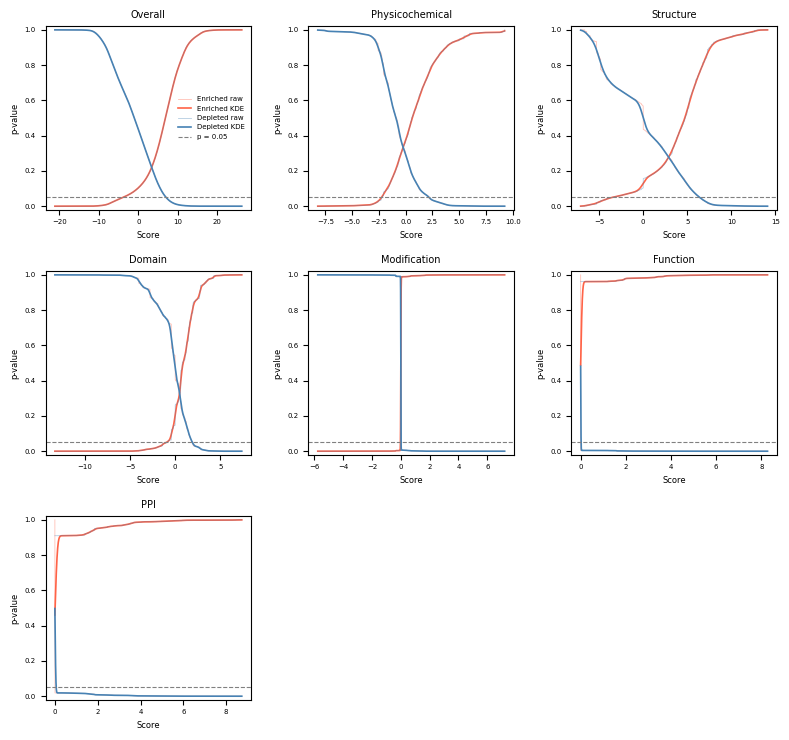

In [31]:
thresholds = {}
for col in SCORE_COLS:
    if col in PRESENCE_BASED:
        thresholds[col] = {'enriched': 0.0, 'depleted': np.nan}
        continue
    sub = lookup[lookup['score_col'] == col]
    enr = sub[sub['p_control'] < 0.05]['pfes_value']
    dep = sub[sub['p_case'] < 0.05]['pfes_value']
    thresholds[col] = {
        'enriched': max(enr.min(),0) if not enr.empty else np.nan,
        'depleted': min(dep.max(),0) if not dep.empty else np.nan,
    }

thresh_df = pd.DataFrame(thresholds).T
thresh_df.index.name = 'score_col'
print("Thresholds (p < 0.05):")
print(thresh_df.to_string(float_format='{:.3f}'.format))

pcols = [c for c in SCORE_COLS if c not in PRESENCE_BASED]
ncols = 3
nrows = int(np.ceil(len(pcols) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(8, nrows * 2.5))
axes = axes.flatten()

for ax in axes[len(pcols):]:
    ax.set_visible(False)

for ax, col in zip(axes, pcols):
    c  = case[col].dropna().values
    ct = control[col].dropna().values

    lo   = min(c.min(), ct.min())
    hi   = max(c.max(), ct.max())
    vals = np.linspace(lo, hi, N_STEPS)

    # Raw empirical
    p_enr_raw = np.array([np.mean(ct >= v) for v in vals])
    p_dep_raw = np.array([np.mean(c  <= v) for v in vals])

    # KDE-smoothed (from lookup)
    sub       = lookup[lookup['score_col'] == col].set_index('pfes_value')
    p_enr_kde = np.interp(vals, sub.index, sub['p_case'])
    p_dep_kde = np.interp(vals, sub.index, sub['p_control'])

    ax.plot(vals, p_enr_raw, color='tomato',    lw=0.6, alpha=0.4, label='Enriched raw')
    ax.plot(vals, p_enr_kde, color='tomato',    lw=1.2,            label='Enriched KDE')
    ax.plot(vals, p_dep_raw, color='steelblue', lw=0.6, alpha=0.4, label='Depleted raw')
    ax.plot(vals, p_dep_kde, color='steelblue', lw=1.2,            label='Depleted KDE')
    ax.axhline(0.05, color='gray', lw=0.8, ls='--', label='p = 0.05')

    label = col.replace('PFES_', '')
    ax.set_title(label if label != 'PFES' else 'Overall', fontsize=7)
    ax.set_xlabel('Score', fontsize=6)
    ax.set_ylabel('p-value', fontsize=6)
    ax.tick_params(labelsize=5)
    ax.set_ylim(-0.02, 1.02)

axes[0].legend(fontsize=5, frameon=False)
plt.tight_layout()
plt.show()

# 4. Distribution histogram with smoothed thresholds

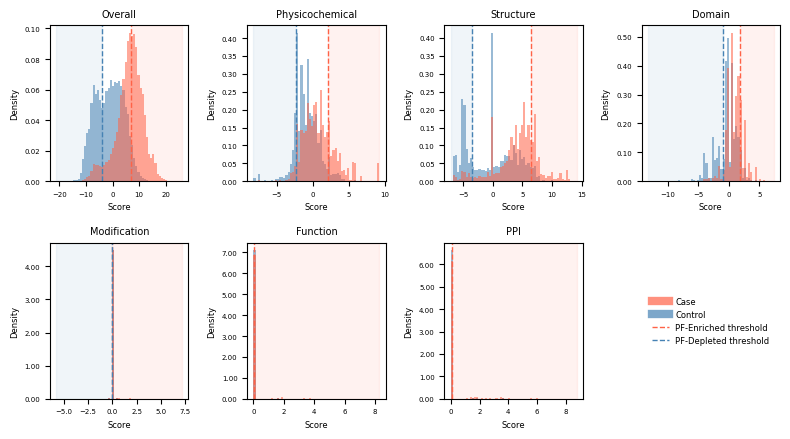

In [32]:

fig, axes = plt.subplots(2, 4, figsize=(8, 4.5))
axes = axes.flatten()

for ax, col in zip(axes, SCORE_COLS):
    c  = case[col].dropna().values
    ct = control[col].dropna().values
    t  = thresholds[col]

    lo   = min(c.min(), ct.min())
    hi   = max(c.max(), ct.max())
    bins = np.linspace(lo, hi, 60)

    ax.hist(ct, bins=bins, density=True, alpha=0.55, color='steelblue')
    ax.hist(c,  bins=bins, density=True, alpha=0.55, color='tomato')

    if not np.isnan(t['enriched']):
        ax.axvline(t['enriched'], color='tomato',    lw=1.0, ls='--')
        ax.axvspan(t['enriched'], hi, alpha=0.08, color='tomato')
    if not np.isnan(t['depleted']):
        ax.axvline(t['depleted'], color='steelblue', lw=1.0, ls='--')
        ax.axvspan(lo, t['depleted'], alpha=0.08, color='steelblue')

    label = col.replace('PFES_', '')
    ax.set_title(label if label != 'PFES' else 'Overall', fontsize=7)
    ax.set_xlabel('Score', fontsize=6)
    ax.set_ylabel('Density', fontsize=6)
    ax.tick_params(labelsize=5)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

axes[-1].axis('off')
handles = [
    plt.Line2D([0], [0], color='tomato',    alpha=0.7, lw=6, label='Case'),
    plt.Line2D([0], [0], color='steelblue', alpha=0.7, lw=6, label='Control'),
    plt.Line2D([0], [0], color='tomato',    lw=1.0, ls='--', label='PF-Enriched threshold'),
    plt.Line2D([0], [0], color='steelblue', lw=1.0, ls='--', label='PF-Depleted threshold'),
]
axes[-1].legend(handles=handles, fontsize=6, frameon=False, loc='center')

plt.tight_layout()
plt.show()

(array([1.27084e+05, 5.60000e+01, 1.55000e+02, 3.50000e+01, 2.13000e+02,
        3.56000e+02, 5.68000e+02, 9.10000e+01, 1.46000e+02, 1.36000e+02,
        2.00000e+00, 5.40000e+01, 3.45000e+02, 1.60000e+01, 5.10000e+01,
        1.00000e+00, 4.50000e+01, 2.00000e+01, 2.10000e+01, 4.10000e+01,
        5.00000e+00, 2.30000e+01, 3.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 7.00000e+00, 0.00000e+00, 0.00000e+00, 1.10000e+01]),
 array([0.        , 0.28216422, 0.56432844, 0.84649266, 1.12865689,
        1.41082111, 1.69298533, 1.97514955, 2.25731377, 2.53947799,
        2.82164221, 3.10380644, 3.38597066, 3.66813488, 3.9502991 ,
        4.23246332, 4.51462754, 4.79679177, 5.07895599, 5.36112021,
        5.64328443, 5.92544865, 6.20761287, 6.48977709, 6.77194132,
        7.05410554, 7.33626976, 7.61843398, 7.9005982 , 8.18276242,
        8.46492664]),
 <BarContainer object of 30 artists>)

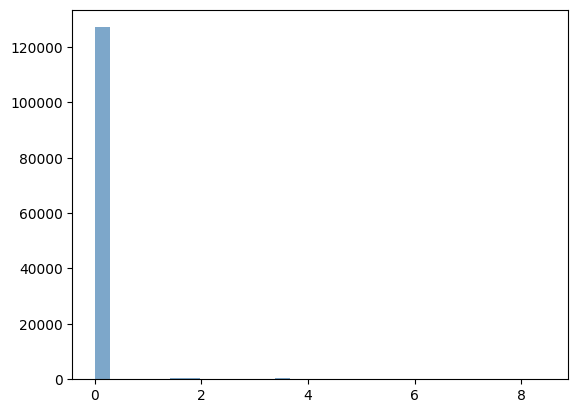

In [33]:
plt.hist(control.PFES_PPI.dropna(), bins=30, color='steelblue', alpha=0.7)

In [34]:
control[control.PFES_PPI < 1]

,Gene,UniProt,ResID,RefAA,AltAA,PFES,PFES_Physicochemical,PFES_Structure,PFES_Domain,PFES_Function,PFES_Modification,PFES_PPI
0,A1BG,P04217,52,H,R,-2.177369,-3.023282,-0.064348,0.910262,0.0,0.000000,0.0
2,A2M,P01023,844,A,V,-3.249123,-1.198581,-2.050542,0.000000,0.0,0.000000,0.0
3,A2M,P01023,1000,I,V,1.604406,-2.182172,3.786578,0.000000,0.0,0.000000,0.0
4,A2ML1,A8K2U0,850,D,E,1.830548,-2.260481,4.091029,0.000000,0.0,0.000000,0.0
5,A2ML1,A8K2U0,970,C,Y,7.185443,2.621520,4.563923,0.000000,0.0,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
130827,ZZEF1,O43149,2525,K,R,-2.581866,-2.573739,0.000000,-0.427964,0.0,0.419838,0.0
130828,ZZZ3,Q8IYH5,251,M,V,-7.315120,-2.061357,-4.825799,-0.427964,0.0,0.000000,0.0
130829,ZZZ3,Q8IYH5,336,N,S,-11.435980,-2.580713,-4.825799,-4.029468,0.0,0.000000,0.0
130830,ZZZ3,Q8IYH5,425,Q,E,-10.729718,-1.874451,-4.825799,-4.029468,0.0,0.000000,0.0
